In [153]:
import matplotlib.pyplot as plt
import cv2
%matplotlib inline

In [154]:
cat4 = cv2.imread("../DATA/CATS_DOGS/train/CAT/4.jpg")
cat4 = cv2.cvtColor(cat4, cv2.COLOR_BGR2RGB)

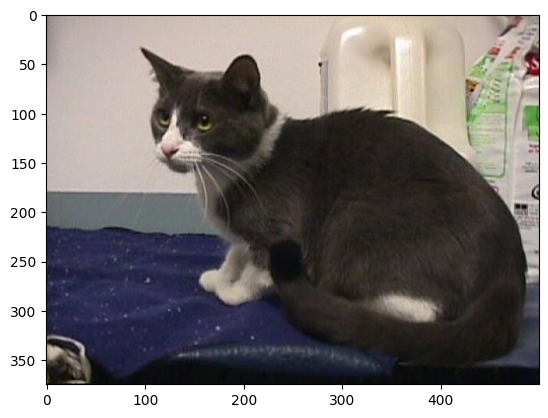

In [155]:
plt.imshow(cat4)

In [156]:
cat4.shape

(375, 500, 3)

In [157]:
dog = cv2.imread("../DATA/CATS_DOGS/train/DOG/2.jpg")
dog = cv2.cvtColor(dog, cv2.COLOR_BGR2RGB)

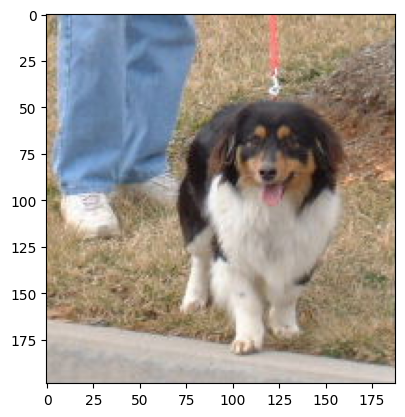

In [158]:
plt.imshow(dog)

In [159]:
dog.shape

(199, 188, 3)

In [160]:
from keras.src.legacy.preprocessing.image import ImageDataGenerator

In [161]:
image_gen = ImageDataGenerator(
    rotation_range=30,
    width_shift_range=0.1,
    height_shift_range=0.1,
    rescale=1/255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode="nearest"
)

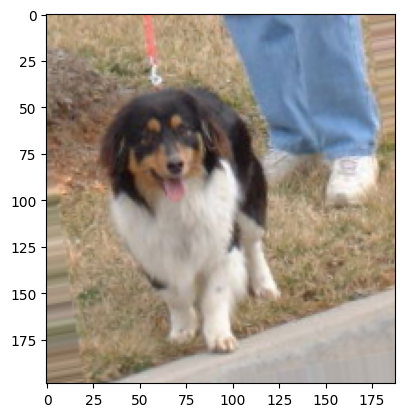

In [162]:
plt.imshow(image_gen.random_transform(dog))

In [163]:
image_gen.flow_from_directory("../DATA/CATS_DOGS/train")

Found 18743 images belonging to 2 classes.


In [164]:
from keras.models import Sequential
from keras.layers import Activation,Dropout,Flatten,Conv2D,MaxPooling2D,Dense

In [165]:
input_shape = (150, 150, 3)

In [166]:
model = Sequential()
model.add(Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Conv2D(filters=64, kernel_size=(3,3), input_shape=input_shape, activation="relu"))
model.add(MaxPooling2D(pool_size=(2,2)))

model.add(Flatten())
model.add(Dense(128))
model.add(Activation("relu"))

model.add(Dropout(0.5))

model.add(Dense(1))

model.add(Activation("sigmoid"))

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)


In [167]:
model.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_24 (Conv2D)              │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_25 (Conv2D)              │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_26 (Conv2D)              │ (None, 34, 34, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 17, 17, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 18496)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     2,367,616 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_14 (Activation)      │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_15 (Activation)      │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,424,065 (9.25 MB)

 Trainable params: 2,424,065 (9.25 MB)

 Non-trainable params: 0 (0.00 B)

In [168]:
batch_size = 16
train_image_gen = image_gen.flow_from_directory(
    "../DATA/CATS_DOGS/train", 
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode="binary"
)
train_image_gen


Found 18743 images belonging to 2 classes.


In [169]:
test_image_gen = image_gen.flow_from_directory(
    "../DATA/CATS_DOGS/test", 
    target_size=input_shape[:2],
    batch_size=batch_size,
    class_mode="binary"
)
test_image_gen

Found 6251 images belonging to 2 classes.


In [170]:
train_image_gen.class_indices

{'CAT': 0, 'DOG': 1}

In [171]:
results = model.fit(
    train_image_gen, 
    epochs=1,
    steps_per_epoch=150,
    validation_data=test_image_gen
)
results

150/150 ━━━━━━━━━━━━━━━━━━━━ 29s 191ms/step - accuracy: 0.4924 - loss: 0.7574 - val_accuracy: 0.5572 - val_loss: 0.6825


In [172]:
import warnings
warnings.filterwarnings("ignore")

In [173]:
results.history["accuracy"]

[0.5083333253860474]

In [174]:
from keras.preprocessing import image
dog_path = "../DATA/CATS_DOGS/test/DOG/9374.jpg"
dog_img = image.load_img(dog_path, target_size=(150,150))
dog_img = image.img_to_array(dog_img)
dog_img.shape


(150, 150, 3)

In [175]:
import numpy as np
dog_img = np.expand_dims(dog_img, axis=0)
dog_img.shape

(1, 150, 150, 3)

In [176]:
dog_img = dog_img / 255
prediction = model.predict(dog_img)
predicted_classes = (prediction > 0.5).astype("int32")
predicted_classes


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


array([[1]], dtype=int32)